# AAMS Week 2 – Discrete-Time Models & Difference Equations

Exercise notebook covering all exercises from the week 2 slides.

**How it works:** Each section has a short theory part at the top, then a function with `# TODO: implement`,
then a test cell. The tests fail until your implementation is correct.
Hints are collapsed and graded – open only as many as you need.
The plotting helpers are finished so you can focus on the models.

Convention as in the lecture: $x_t = F(x_{t-1})$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110


def plot_timeseries(ts, labels=None, title="", logy=False, ax=None):
    ts = np.asarray(ts, dtype=float)
    if ts.ndim == 1:
        ts = ts[:, None]
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 3.5))
    for i in range(ts.shape[1]):
        ax.plot(ts[:, i], marker="o", ms=3, label=labels[i] if labels else None)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("t")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    if labels:
        ax.legend()
    return ax


def plot_phase(ts, labels=("x", "y"), title="Phase space", ax=None):
    ts = np.asarray(ts, dtype=float)
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.plot(ts[:, 0], ts[:, 1], "-o", ms=3, color="purple", lw=1)
    ax.plot(ts[0, 0], ts[0, 1], "o", color="red", label="Initial condition")
    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    return ax


def plot_cobweb(f, path, xlim, title="", ax=None):
    path = np.asarray(path, dtype=float)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    xs = np.linspace(*xlim, 400)
    ax.plot(xs, f(xs), "k", label=r"$x_t = f(x_{t-1})$")
    ax.plot(xlim, xlim, "k--", lw=0.8, label=r"$x_t = x_{t-1}$")
    ax.plot([path[0, 0], path[0, 0]], [xlim[0], path[0, 1]], "r", lw=1)
    ax.plot(path[:, 0], path[:, 1], "r", lw=1, label="Cobweb")
    ax.set_xlim(xlim)
    ax.set_ylim(xlim)
    ax.set_xlabel(r"$x_{t-1}$")
    ax.set_ylabel(r"$x_t$")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
    return ax

## 0 · The simulator

A first-order difference equation is simulated by applying the update rule $T$ times, starting from the
initial state $x_0$. The result is a time series $\{x_0, x_1, \dots, x_T\}$.
You'll need this simulator in almost every section below – build it once, cleanly.

**Contract:** `step` takes a state (scalar or vector) and returns the next one.
The return value is an `np.ndarray` of shape `(T+1,)` for scalars or `(T+1, dim)` for vectors, including the initial state.

In [ ]:
def simulate(step, state0, T):
    '''Returns the time series of all states from t=0 to t=T.'''
    state0 = np.asarray(state0, dtype=float)
    ts = np.empty((T + 1,) + state0.shape, dtype=float)
    ts[0] = state0
    for t in range(1, T + 1):
        ts[t] = step(ts[t - 1])
    return ts

In [ ]:
# Tests
assert np.allclose(simulate(lambda x: 2 * x, 1, 3), [1, 2, 4, 8])
assert simulate(lambda x: 2 * x, 1, 3).shape == (4,)
out = simulate(lambda s: s + 1, np.array([0, 10]), 2)
assert out.shape == (3, 2) and np.allclose(out, [[0, 10], [1, 11], [2, 12]])
print("✓ simulate")

<details><summary>Hint 1</summary>

Remember that the initial state is part of the time series – `T` steps give you `T+1` entries.

</details>

<details><summary>Hint 2</summary>

`np.asarray(..., dtype=float)` saves you trouble when someone passes in integers or lists.

</details>

## 1 · Two interacting components (Ex. 4.1 / 4.2)

Red = $1$, Blue = $-1$, (White = $0$). The rules are applied **simultaneously**: both new states depend only on the
*old* states. A linear system can be written as a matrix: $\mathbf{s}_t = A\,\mathbf{s}_{t-1}$.

**a)** A tries to stay the same colour as B, B tries to be the opposite of A. Start: both blue.
**b)** A becomes the sum of A and B, B becomes the opposite of A. Start: A red, B white.

In [ ]:
def F_two(s):
    '''One time step of the two-colour system; s = (s_A, s_B).'''
    # TODO: implement
    raise NotImplementedError

A_two = None  # TODO: matrix form


def F_three(s):
    '''One time step of the three-colour system; s = (s_A, s_B).'''
    # TODO: implement
    raise NotImplementedError

A_three = None  # TODO: matrix form

In [ ]:
# Tests
ts = simulate(F_two, [-1, -1], 4)
assert np.allclose(ts, [[-1, -1], [-1, 1], [1, 1], [1, -1], [-1, -1]]), ts
ts3 = simulate(F_three, [1, 0], 6)
assert np.allclose(ts3, [[1, 0], [1, -1], [0, -1], [-1, 0], [-1, 1], [0, 1], [1, 0]]), ts3
for s in ([1, 0], [-1, 1], [0, -1]):
    assert np.allclose(A_two @ np.array(s), F_two(s))
    assert np.allclose(A_three @ np.array(s), F_three(s))
print("✓ colour systems")
print("Two-colour time series:", ts.tolist())

<details><summary>Hint 1</summary>

Translate each sentence of the rule into one equation for the new component. "Opposite" in the ±1 encoding is a sign flip.

</details>

<details><summary>Hint 2</summary>

For the matrix: row $i$ holds the coefficients with which the old states enter new component $i$.

</details>

**Question:** What behaviour arises in each case? And what happens in the three-colour system if you start at `[1, 1]`?

<details><summary>Answer</summary>


a) Periodic with period 4, b) periodic with period 6.
Starting at `[1, 1]` gives $s_A = 2$ – that's not a valid colour. The rule is only closed on the state space
$\{-1, 0, 1\}^2$ for certain initial conditions. The slide doesn't mention this, but it's good model criticism.


</details>

## 2 · Classification (Ex. 4.3 + exercise in Part VII) – pen & paper

- **Linear:** only linear combinations of state variables (constant × variable, constant, sums).
  Functions of *parameters* or of $t$ do **not** make an equation nonlinear.
- **Order:** the largest delay – only $t-1$ → first order.
- **Autonomous:** $t$ (or external variables) does not appear explicitly on the right-hand side.

| # | Equation |
|---|---|
| 1 | $x_t = a x_{t-1} + b$ |
| 2 | $x_t = a x_{t-1} + b x_{t-2} + c x_{t-3}$ |
| 3 | $x_t = a x_{t-1}(1 - x_{t-1})$ |
| 4 | $x_t = a x_{t-1} + b x_{t-2}^2 + c\sqrt{x_{t-1} x_{t-3}}$ |
| 5 | $x_t = a x_{t-1} x_{t-2} + b x_{t-3} + \sin t$ |
| 6 | $x_t = a x_{t-1} + b y_{t-1},\; y_t = c x_{t-1} + d y_{t-1}$ |
| 7 | $x_t = x_{t-1} + t$ |
| 8 | $x_t = -\sin(a)\, x_{t-2}$ |
| 9 | $x_t = x_{t-1}^2 + 1 - b^2$ |

<details><summary>Solution</summary>


| # | linear? | order | autonomous? |
|---|---|---|---|
| 1 | linear | 1 | autonomous |
| 2 | linear | 3 | autonomous |
| 3 | nonlinear | 1 | autonomous |
| 4 | nonlinear | 3 | autonomous |
| 5 | nonlinear ($x_{t-1}x_{t-2}$) | 3 | non-autonomous ($\sin t$) |
| 6 | linear | 1 | autonomous |
| 7 | linear | 1 | non-autonomous |
| 8 | linear ($\sin a$ is just a constant) | 2 | autonomous |
| 9 | nonlinear | 1 | autonomous ($b^2$ is constant) |

On #4: the term is hard to read in the slide image. If you read it as $b\,x\,t$, the equation would also be non-autonomous.


</details>

## 3 · Converting to autonomous first-order form (Ex. 4.4)

**Trick:** Introduce a new variable for each delay ($y_t = x_{t-1}$, $z_t = y_{t-1}$, …)
and a counter variable for time ($z_t = z_{t-1} + 1$). The new state is then a vector that carries all the
history the rule needs.

1. $x_t = x_{t-1}(1 - x_{t-1})\sin t$ → state $(x, z)$
2. $x_t = x_{t-1} + x_{t-2} - x_{t-3}$ → state $(x, y, z)$

In [ ]:
def step_44_1(state):
    '''Autonomous form of x_t = x_{t-1}(1 - x_{t-1}) sin t; state = (x, z).'''
    # TODO: implement
    raise NotImplementedError

z0_44_1 = None  # TODO: which initial value of z belongs with x_0?


def step_44_2(state):
    '''Autonomous form of x_t = x_{t-1} + x_{t-2} - x_{t-3}; state = (x, y, z).'''
    # TODO: implement
    raise NotImplementedError

In [ ]:
# Tests
ts = simulate(step_44_1, [0.5, z0_44_1], 5)
assert np.allclose(ts[:, 0], [0.5, 0.210368, 0.151046, 0.018096, -0.013447, 0.013068], atol=1e-5), ts[:, 0]

# Original with x_0 = 1, x_1 = 0, x_2 = 2  ->  state at t = 2: (x_2, x_1, x_0)
ts = simulate(step_44_2, [2, 0, 1], 4)
assert np.allclose(ts[:, 0], [2, 1, 3, 2, 4]), ts[:, 0]
print("✓ conversions")

<details><summary>Hint 1</summary>

Write down the definition of the new variable (e.g. $y_t = x_{t-1}$) and ask yourself: what is $y_{t-1}$ in terms of $x$?

</details>

<details><summary>Hint 2</summary>

For the time counter: in the update for $x_t$, only time $t-1$ may appear on the right. What value must $z_{t-1}$ have to replace $t$ – and what does that imply for $z_0$?

</details>

## 4 · Fibonacci in matrix form (Ex. 4.8)

$x_t = x_{t-1} + x_{t-2}$, $x_0 = x_1 = 1$. With $y_t = x_{t-1}$ this becomes a linear first-order system
$\begin{pmatrix}x\\y\end{pmatrix}_t = A \begin{pmatrix}x\\y\end{pmatrix}_{t-1}$.
The ratio $x_t / x_{t-1}$ converges to the golden ratio $\varphi = \frac{1+\sqrt5}{2}$.

**Question from the slide:** What initial conditions does the first-order system need?

In [ ]:
A_fib = None  # TODO


def fib_matrix(n):
    '''Returns x_0, ..., x_n (x_0 = x_1 = 1) as an array, computed via the matrix form.'''
    # TODO: implement
    raise NotImplementedError


def golden_ratio(n):
    '''Estimate of phi as x_n / x_{n-1}.'''
    # TODO: implement
    raise NotImplementedError

In [ ]:
# Tests
assert np.allclose(fib_matrix(9), [1, 1, 2, 3, 5, 8, 13, 21, 34, 55])
assert abs(golden_ratio(30) - (1 + np.sqrt(5)) / 2) < 1e-10
print("✓ Fibonacci, phi ≈", golden_ratio(30))

ratios = [golden_ratio(n) for n in range(2, 20)]
ax = plot_timeseries(ratios, title=r"$x_t/x_{t-1}$ → $\varphi$")
ax.axhline((1 + np.sqrt(5)) / 2, color="k", ls="--", lw=0.8);

<details><summary>Hint 1</summary>

The second row of the matrix only has to "copy" – which old component becomes the new $y$?

</details>

<details><summary>Hint 2</summary>

For the initial condition: the state at time $t$ is $(x_t, x_{t-1})$. You can start at $t=1$ with $(x_1, x_0)$ – or at $t=0$ with a fictitious $x_{-1}$ that keeps the recurrence consistent.

</details>

<details><summary>Hint 3</summary>

Bonus: `np.linalg.eigvals(A_fib)` – do you recognise one of the eigenvalues?

</details>

<details><summary>Answer</summary>


You need **two** values, because the original is second order. Either $(x_1, y_1) = (1, 1)$ at $t = 1$,
or equivalently $(x_0, y_0) = (1, 0)$, since $x_{-1} = x_1 - x_0 = 0$. The largest eigenvalue of $A$ is exactly $\varphi$ –
which is why the sequence grows asymptotically like $\varphi^t$.


</details>

## 5 · Linear vs. exponential growth (exercise Exponential Growth / Decay)

- Linear: $x_t = x_{t-1} + a \;\Rightarrow\; x_t = x_0 + a t$
- Exponential: $x_t = b\,x_{t-1} \;\Rightarrow\; x_t = b^t x_0$ – growth for $b > 1$, decay for $0 < b < 1$.

Plot with a logarithmic y-axis. **Question:** What is the slope of the line?

In [ ]:
def linear_growth(a, x0, T):
    '''Time series x_0..x_T for x_t = x_{t-1} + a.'''
    # TODO: implement
    raise NotImplementedError


def exponential(b, x0, T):
    '''Time series x_0..x_T for x_t = b * x_{t-1}.'''
    # TODO: implement
    raise NotImplementedError

In [ ]:
# Tests
assert np.allclose(linear_growth(3, 1, 3), [1, 4, 7, 10])
assert np.allclose(exponential(2, 1, 10), 2.0 ** np.arange(11))
assert np.allclose(exponential(0.5, 100, 2), [100, 50, 25])
print("✓ growth models")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for b in [0.5, 0.8, 1.0, 1.5, 2.0]:
    ts = exponential(b, 1, 10)
    axes[0].plot(ts, label=f"b={b}")
    axes[1].plot(ts, label=f"b={b}")
axes[1].set_yscale("log")
for ax, t in zip(axes, ["linear", "log-y"]):
    ax.set_title(t); ax.set_xlabel("t"); ax.legend(); ax.grid(alpha=0.3)

<details><summary>Answer: slope</summary>


$\log x_t = \log x_0 + t \log b$. On a log axis this is a straight line with slope $\log b$
(with `log10`, that's $\log_{10} b$ per time step). For $b = 2$: $\approx 0.301$ decades per step,
for $b = 0.5$ the same number, negative. For $b = 1$ the slope is 0.


</details>

## 6 · Linear with a constant term (Ex. 4.6)

$x_t = a x_{t-1} + b$, $x_0 = 1$ – e.g. a fish population with a fixed fishing quota, or credit card debt with fixed
monthly payments (both $b < 0$). Vary $a$ and $b$: is the behaviour the same as simple exponential growth/decay?

In [ ]:
def affine(a, b, x0, T):
    '''Time series x_0..x_T for x_t = a * x_{t-1} + b.'''
    # TODO: implement
    raise NotImplementedError


def affine_fixed_point(a, b):
    '''Equilibrium x* with x* = a x* + b (for a != 1).'''
    # TODO: implement
    raise NotImplementedError

In [ ]:
# Tests
assert np.allclose(affine(1, 2, 1, 3), [1, 3, 5, 7])
assert np.isclose(affine(0.5, 1, 1, 200)[-1], 2.0)
assert np.isclose(affine_fixed_point(0.5, 1), 2.0)
xs = affine(1.1, -5, affine_fixed_point(1.1, -5), 20)
assert np.allclose(xs, xs[0])
print("✓ affine")

ax = None
for a, b in [(0.5, 1), (1.1, -0.5), (1.1, 0.5), (-0.8, 1), (1.0, 0.3)]:
    ax = plot_timeseries(affine(a, b, 1, 25), ax=ax)
    ax.lines[-1].set_label(f"a={a}, b={b}")
ax.legend(); ax.set_title("x_t = a x_{t-1} + b");

<details><summary>Hint 1</summary>

At equilibrium set $x_t = x_{t-1} = x^*$ and solve for $x^*$.

</details>

<details><summary>Answer</summary>


Yes – qualitatively the same, just shifted around the fixed point $x^* = b/(1-a)$ instead of around $0$.
With $u_t = x_t - x^*$ you get $u_t = a\,u_{t-1}$, i.e. pure exponential behaviour of the deviation.
$|a| < 1$: convergence to $x^*$; $|a| > 1$: divergence away from $x^*$ (the fish population collapses or explodes
depending on the initial value); $a < 0$: alternating; $a = 1$: linear drift.


</details>

## 7 · Multiple variables & phase space (Ex. 4.7)

$$x_t = 0.5x_{t-1} + y_{t-1},\qquad y_t = -0.5x_{t-1} + y_{t-1},\qquad x_0 = y_0 = 1$$

In phase space, each axis is a state variable and one point is the complete system state.
**Watch out (slide \"Carefully review where you update the variables\"):** all new values may only use old values.
The test checks exactly this trap.

In [ ]:
A_414 = None  # TODO


def step_2d(state, A):
    '''One step of the linear 2D system state_t = A state_{t-1}.'''
    # TODO: implement
    raise NotImplementedError

In [ ]:
# Tests
first = step_2d(np.array([1.0, 1.0]), A_414)
assert not np.allclose(first, [1.5, 0.25]), "y was computed with the NEW x – see the slide!"
assert np.allclose(first, [1.5, 0.5]), first
print("✓ 2D system")

systems = {
    "4.14 (slide)": A_414,
    "damped": np.array([[0.5, 0.5], [-0.5, 0.5]]),
    "growing": np.array([[0.6, 1.2], [-0.6, 1.0]]),
}
fig, axes = plt.subplots(2, len(systems), figsize=(13, 7))
for j, (name, A) in enumerate(systems.items()):
    ts = simulate(lambda s: step_2d(s, A), [1, 1], 20)
    plot_timeseries(ts, labels=["x", "y"], title=f"{name}  |λ|max={max(abs(np.linalg.eigvals(A))):.2f}", ax=axes[0, j])
    plot_phase(ts, ax=axes[1, j])
plt.tight_layout()

**Experiment:** Change the coefficients. Which classes of behaviour can you find?
Compare with the eigenvalues (`np.linalg.eigvals`).

<details><summary>Interpretation</summary>


Stationary, exponential growth/decay, oscillation and their combinations (growing/damped spirals) –
a linear system can't do more. The eigenvalues predict it: $|\lambda| < 1$ decay, $|\lambda| > 1$ growth,
complex $\lambda$ rotation/oscillation. The slide matrix has $\det A = 1$, so $|\lambda| = 1$ → closed ellipse.
The left slide plot (inward spiral) is produced by exactly the update bug.


</details>

## 8 · Logistic growth (Ex. 4.9)

Idea: replace the growth factor $a$ with $f(x)$, where $f(0) = a$ and $f(K) = 1$ (a straight line, KISS). With $r = a - 1$:

$$x_t = \underbrace{x_{t-1}}_{\text{current population}} + \underbrace{r\,x_{t-1}\left(1 - \frac{x_{t-1}}{K}\right)}_{\text{newborns}}$$

Task: plot the population and the increase per step $\Delta x_t = x_t - x_{t-1}$, compare with linear/exponential,
and try different $r$ and $x_0$.

In [ ]:
def logistic_step(x, r, K):
    '''One step of the discrete logistic model.'''
    # TODO: implement
    raise NotImplementedError

In [ ]:
# Tests
assert np.isclose(logistic_step(1000, 0.3, 1000), 1000)   # no growth at K
assert np.isclose(logistic_step(0, 0.3, 1000), 0)         # no population, nothing happens
assert np.isclose(logistic_step(0.1, 1, 1), 0.19)
print("✓ logistic")

T, K, r, x0 = 40, 1000, 0.3, 10
log_ = simulate(lambda x: logistic_step(x, r, K), x0, T)
exp_ = exponential(1 + r, x0, T)
lin_ = linear_growth(20, x0, T)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for ts, lab, st in [(log_, "logistic", "-"), (exp_, "exponential", "--"), (lin_, "linear", ":")]:
    a1.plot(ts, st, label=lab)
    a2.plot(range(1, T + 1), np.diff(ts), st, label=lab)
a1.axhline(K, color="gray", ls="-.", label="K"); a1.set_ylim(0, 1.2 * K)
a2.set_ylim(0, 120)
a1.set_title("Population"); a2.set_title("Increase per time step")
for ax in (a1, a2): ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel("t")

In [ ]:
# Exploration: different r and x0 (K = 1)
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, r in zip(axes, [0.5, 1.5, 2.3, 2.8]):
    for x0 in [0.05, 0.5, 1.3]:
        ax.plot(simulate(lambda x: logistic_step(x, r, 1), x0, 40), lw=1, label=f"x0={x0}")
    ax.set_title(f"r = {r}"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8);

<details><summary>What you should see</summary>


For $0 < r < 2$ everything (with $x_0 > 0$) converges to $K$ – for $r > 1$ with overshoot/alternation.
Above $r > 2$, $K$ becomes unstable: a 2-cycle, then a 4-cycle, and chaos from about $r \approx 2.57$.
That's behaviour no linear system can show. The increase per step is largest at $x = K/2$.


</details>

## 9 · Predator–prey (Ex. 4.11 – 4.13)

$$x_t = x_{t-1} + r x_{t-1}\left(1 - \frac{x_{t-1}}{K}\right) - \left(1 - \frac{1}{b\,y_{t-1} + 1}\right) x_{t-1}$$
$$y_t = y_{t-1} - d\,y_{t-1} + c\,x_{t-1}\,y_{t-1}$$

Prey grows logistically, predators die out without prey. The prey death rate rises with $y$ (saturating at 1),
the predator growth rate rises with $x$. Reference: all parameters $= 1$, $K = 5$, $x_0 = y_0 = 1$.

In [ ]:
def predator_prey_step(state, r=1.0, K=5.0, b=1.0, d=1.0, c=1.0):
    '''One step of the predator-prey model (Eq. 4.34/4.35); state = (x, y).'''
    x, y = state
    x_new = x + r * x * (1 - x / K) - (1 - 1 / (b * y + 1)) * x
    y_new = y - d * y + c * x * y
    return (x_new, y_new)

In [ ]:
# Tests – incl. Ex. 4.11 (extreme values)
assert np.allclose(predator_prey_step([1, 4]), [1, 4]), "(1, 4) is the equilibrium for the reference parameters"
assert np.allclose(predator_prey_step([1, 0]), [1.8, 0]), "no predators: purely logistic"
assert np.allclose(predator_prey_step([0, 4], d=0.5), [0, 2]), "no prey: predators decay"
assert np.allclose(predator_prey_step([5, 0]), [5, 0]), "no predators at K: stationary"
print("✓ predator-prey")

ts = simulate(predator_prey_step, [1, 1], 100)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
plot_timeseries(ts, labels=["prey x", "predators y"], title="Reference (Fig. 4.8)", ax=a1)
plot_phase(ts, labels=("prey x", "predators y"), ax=a2);

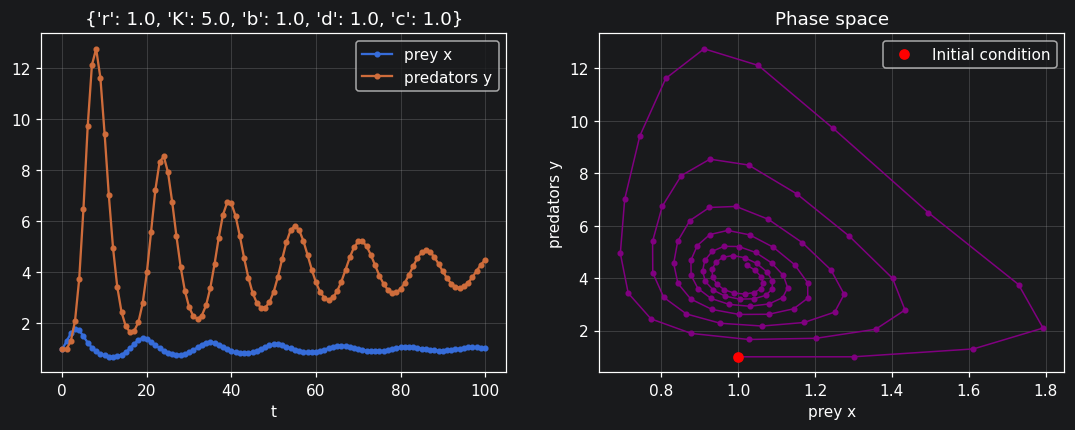

In [20]:
# Ex. 4.13: vary parameters one at a time. Change the values here.
params = dict(r=1.0, K=5.0, b=1.0, d=1.0, c=1.0)
ts = simulate(lambda s: predator_prey_step(s, **params), [1, 1], 100)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
plot_timeseries(ts, labels=["prey x", "predators y"], title=str(params), ax=a1)
plot_phase(ts, labels=("prey x", "predators y"), ax=a2);

<details><summary>Hint 1</summary>

For Ex. 4.13: try e.g. a much larger `c` or a very large `K`. Which term then grows without bound?

</details>

<details><summary>Hint 2</summary>

The predator growth rate $r_y(x) = cx$ has no upper limit. How did $d_x(y)$ get its saturation? Use tip 3 from \"Building your own model\": replace the term with an unknown function, then design the function.

</details>

<details><summary>Hint 3</summary>

Also watch for negative populations – a sign that one time step subtracts "too much".

</details>

<details><summary>Why (1, 4)?</summary>


Equilibrium: the $y$ equation gives $x^* = d/c = 1$; plugging that into the $x$ equation gives $r(1 - 1/K) = 1 - 1/(by^*+1)$ → $y^* = 4$.
The reference simulation spirals into it with damping, which matches Fig. 4.8: prey oscillates around 1, predators around 4.


</details>

## 10 · Leslie model (age-structured)

$\mathbf{n}_t = L\,\mathbf{n}_{t-1}$. First row: fecundities $f_i$ = average number of offspring per individual
in class $i$ (can be $> 1$!). Subdiagonal: survival rates $s_i$ from class $i$ to $i+1$.
The long-term behaviour is determined by the **dominant eigenvalue** $\lambda$: $>1$ growth, $=1$ stable, $<1$ decline.

In [18]:
L1 = np.array([[0, 4.5, 4.5], [0.42, 0, 0], [0, 0.60, 0]])
L2 = np.array([[0, 4/3, 4/3], [0.50, 0, 0], [0, 0.50, 0]])
L3 = np.array([[0, 0.9, 0.9], [0.50, 0, 0], [0, 0.50, 0]])

In [17]:
def leslie_simulate(L, n0, T):
    '''Age distributions n_0..n_T as an array of shape (T+1, k).'''
    k = len(n0)

    # Initialize a 2D array to hold the population at each time step
    history = np.zeros((T + 1, k))
    history[0] = n0

    # Project the population forward T times
    for t in range(T):
        history[t + 1] = L @ history[t]

    return history

def dominant_eigenvalue(L):
    '''Eigenvalue of L with the largest absolute value.'''
    # Calculate all eigenvalues of the matrix
    eigenvalues, _ = np.linalg.eig(L)

    # Find the index of the eigenvalue with the maximum absolute magnitude
    dom_index = np.argmax(np.abs(eigenvalues))

    # Return the dominant eigenvalue (typically real and positive for Leslie matrices)
    return eigenvalues[dom_index]

✓ Leslie


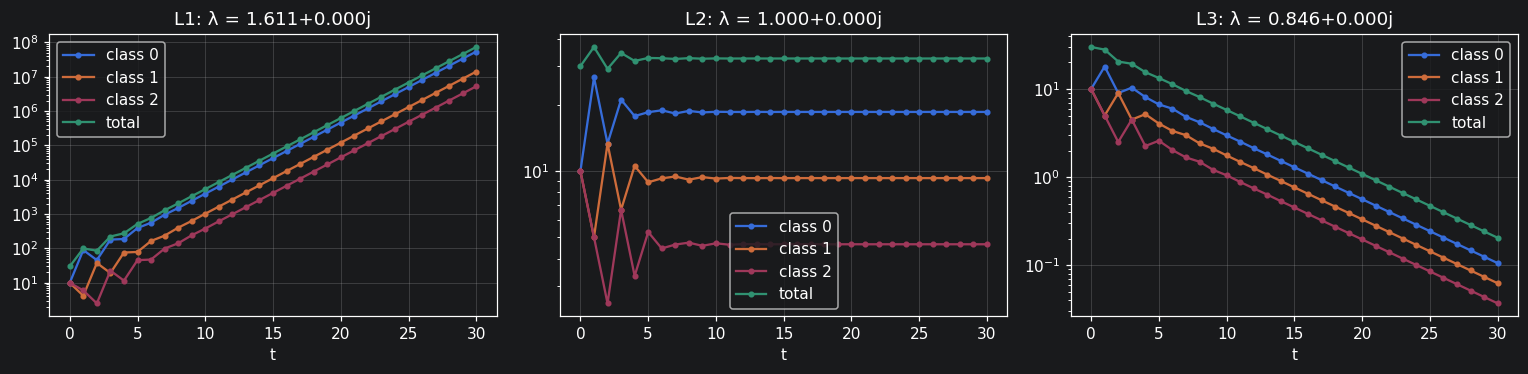

In [19]:
# Tests
n = leslie_simulate(L1, [10, 10, 10], 2)
assert n.shape == (3, 3) and np.allclose(n[1], [90, 4.2, 6.0])
assert np.isclose(dominant_eigenvalue(L1), 1.6106, atol=1e-3)
assert np.isclose(dominant_eigenvalue(L2), 1.0)
assert np.isclose(dominant_eigenvalue(L3), 0.8461, atol=1e-3)
print("✓ Leslie")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (name, L) in zip(axes, [("L1", L1), ("L2", L2), ("L3", L3)]):
    ts = leslie_simulate(L, [10, 10, 10], 30)
    plot_timeseries(np.column_stack([ts, ts.sum(1)]), labels=["class 0", "class 1", "class 2", "total"],
                    title=f"{name}: λ = {dominant_eigenvalue(L):.3f}", logy=True, ax=ax)
plt.tight_layout()

**Question:** What do the entries mean, e.g. $4.5$ and $0.42$ in $L_1$? And why does $L_2$ stabilise?
Tip: compute $f_1 s_0 + f_2 s_0 s_1$ (expected offspring per newborn over its whole life).

<details><summary>Answer</summary>


$4.5$: an individual in class 1 (or 2) has on average 4.5 offspring per time step.
$0.42$: 42 % of newborns survive to age 1. The lifetime reproductive number
$R_0 = f_1 s_0 + f_2 s_0 s_1$ is, for $L_1$: $1.89 + 1.134 = 3.02 > 1$; for $L_2$: $\tfrac23 + \tfrac13 = 1$
(exact replacement); for $L_3$: $0.675 < 1$. $R_0 > 1 \Leftrightarrow \lambda > 1$.
For $L_2$ the total size stays constant after a transient, and the age distribution converges.


</details>

## 11 · Two competing species (Ex. 4.14)

Assumptions of the reference solution: each time step, an amount $R$ of resource becomes available and is fully consumed.
Each species gets a share proportional to its population size, and population increase is proportional to the resource consumed:

$$x_t = x_{t-1} + r_x R\,\frac{x_{t-1}}{x_{t-1}+y_{t-1}},\qquad y_t = y_{t-1} + r_y R\,\frac{y_{t-1}}{x_{t-1}+y_{t-1}}$$

Try designing your own model first – the exercise is open-ended.

In [ ]:
def competition_step(state, rx, ry, R):
    '''One step of the resource competition model; state = (x, y).'''
    # TODO: implement
    raise NotImplementedError

In [ ]:
# Tests
s = competition_step([1, 3], rx=0.5, ry=0.5, R=8)
assert np.allclose(s, [2, 6]), "equal rates -> ratio is preserved"
assert np.isclose(s.sum() - 4, 0.5 * 8)
print("✓ competition")

ts = simulate(lambda s: competition_step(s, rx=1.2, ry=1.0, R=10), [1, 5], 500)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.5))
plot_timeseries(ts, labels=["x", "y"], title="Populations", ax=a1)
plot_timeseries(ts[:, 0] / ts.sum(1), title="Share of x", ax=a2);

**Question:** The slide says the species with the higher rate "wins". Does the other one die out?

<details><summary>Answer</summary>


No. Both increases are always positive, so both populations grow forever (the total grows roughly linearly).
\"Winning\" only means the **share** goes to 1 – and slowly (polynomially, not exponentially).
After $10^5$ steps with $r_x = 2$, $r_y = 1$, $x$ only has a ~99.85 % share, while $y$ has grown to ~3000.
A more realistic model would need mortality – a good reason to extend the model yourself.


</details>

## 12 · Cobweb plots (Ex. 5.6 / 5.7)

For 1D maps $x_t = f(x_{t-1})$: draw the curve $f$ and the diagonal, then alternate
**vertically to the curve, horizontally to the diagonal**. Intersections of curve and diagonal = fixed points.
Staircase/spiral inwards = convergence, outwards = divergence.

**Contract:** `cobweb_path` returns the corner points $(x_0,x_0), (x_0,x_1), (x_1,x_1), (x_1,x_2), \dots$ –
$2n+1$ points in total for $n$ iterations. `plot_cobweb` does the drawing.

In [ ]:
def cobweb_path(f, x0, n):
    '''Corner points of the cobweb path for n iterations, array of shape (2n+1, 2).'''
    # TODO: implement
    raise NotImplementedError

In [ ]:
# Tests
assert np.allclose(cobweb_path(lambda x: 2 * x, 1, 2), [[1, 1], [1, 2], [2, 2], [2, 4], [4, 4]])
assert cobweb_path(np.cos, 0.3, 10).shape == (21, 2)
print("✓ cobweb_path")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
f_exp = lambda x: 1.1 * x
plot_cobweb(f_exp, cobweb_path(f_exp, 1, 32), (0, 20), "Exponential a=1.1, x0=1", ax=axes[0])
f_r1 = lambda x: logistic_step(x, 1, 1)
plot_cobweb(f_r1, cobweb_path(f_r1, 0.1, 20), (0, 1), "Ex. 5.6: logistic r=1", ax=axes[1])
f_r25 = lambda x: logistic_step(x, 2.5, 1)
plot_cobweb(f_r25, cobweb_path(f_r25, 0.1, 60), (0, 1.4), "Ex. 5.7: logistic r=2.5", ax=axes[2])
plt.tight_layout()

<details><summary>Interpretation</summary>


- Exponential $a = 1.1$: the curve lies above the diagonal, the only fixed point is 0 (unstable) → staircase outwards.
- Logistic $r = 1$: monotone staircase up to the stable fixed point $K = 1$.
- Logistic $r = 2.5$: the slope of $f$ at $K$ is $1 - r = -1.5$, so $|f'(K)| > 1$ → $K$ is unstable.
  The path settles into a **4-cycle**. Rule of thumb: a fixed point is stable $\Leftrightarrow |f'(x^*)| < 1$, here for $0 < r < 2$.


</details>

## 13 · Reflection: growth models (exercise in Part VII)

Write down the three models and find one application for each where the model is plausible – with a justification.
Criterion: *what* changes per time step – a fixed amount, a fixed fraction, or a fraction that shrinks as the population grows?

| Model | Equation | Your application | Why plausible? |
|---|---|---|---|
| linear | | | |
| exponential | | | |
| logistic | | | |

## Notes on the slides

- **Three-colour example:** the solution labels the colours \"A/B/C\", although A and B are the components – confusing.
  The model also isn't closed for all initial conditions (see section 1).
- **Leslie parameters:** the slide calls $f_i$ a \"proportion\". It's the average number of offspring – otherwise values like 4.5 would be impossible.
  The Leslie slide also uses the convention $n_{t+1} = L n_t$ instead of $x_t = F(x_{t-1})$ – same content.
- **Competition model:** \"proposal\" is a typo for \"proportional\", and the $t-1$ subscripts are missing on the right-hand side.
  \"Winning\" is only meant relatively (see section 11).
- **Multiple Variables:** the left plot (inward spiral) is the result of the update bug, the right one (ellipse) is correct.
- **Cobweb solution:** the plots use the axis labels $x_t \to x_{t+1}$ instead of the course convention.
  The decay plot ($a = 0.8$, $x_0 = 20$) isn't part of the exercise as set, but it's a useful counterpart.